# Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the historical characteristics of Bitcoin, Ethereum, Gold, and the S&P 500 through exploratory data analysis.

The analysis focuses on identifying trends, variability, and overall market behaviour that will guide the statistical analyses performed in later stages of the project.

### Importing Libraries & Loading Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

In [2]:
PROCESSED_DATA_PATH = Path("crypto_project/data/processed")

market = pd.read_csv(
    PROCESSED_DATA_PATH / "market_data_master.csv"
)

market["Date"] = pd.to_datetime(market["Date"])

In [3]:
# Dark crypto theme
plt.style.use("dark_background")

crypto_palette = {
    "Bitcoin": "#F7931A",   # Orange
    "Ethereum": "#627EEA",  # Blue
    "Gold": "#FFD700",      # Gold
    "SP500": "#2ECC71"      # Green
}
sns.set_theme(
    style="darkgrid",
    context="talk",
)

### Dataset Overview

In [4]:
market.head()

,Date,Close,High,Low,Open,Volume,Asset
0,2019-01-01,3843.520020,3850.913818,3707.231201,3746.713379,4324200990,Bitcoin
1,2019-01-01,140.819412,141.397507,132.650711,133.418152,2258709868,Ethereum
2,2019-01-02,3943.409424,3947.981201,3817.409424,3849.216309,5244856836,Bitcoin
3,2019-01-02,155.047684,156.929138,140.650955,141.519516,3328240369,Ethereum
4,2019-01-02,121.330002,121.750000,120.879997,121.349998,12776200,Gold


In [5]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7404 entries, 0 to 7403
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    7404 non-null   datetime64[ns]
 1   Close   7404 non-null   float64       
 2   High    7404 non-null   float64       
 3   Low     7404 non-null   float64       
 4   Open    7404 non-null   float64       
 5   Volume  7404 non-null   int64         
 6   Asset   7404 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 405.0+ KB


In [6]:
market.describe()

,Date,Close,High,Low,Open,Volume
count,7404,7404.000000,7404.000000,7404.000000,7404.000000,7.404000e+03
mean,2021-12-31 05:46:58.152349952,10682.416258,10893.672522,10438.621052,10670.333771,1.434177e+10
min,2019-01-01 00:00:00,104.535301,106.058876,95.184303,104.645050,0.000000e+00
25%,2020-07-01 00:00:00,228.161152,231.960003,224.617542,227.961292,3.486665e+09
50%,2021-12-30 12:00:00,3175.812988,3234.420044,3115.949951,3173.124146,8.303850e+09
75%,2023-07-03 00:00:00,8844.972900,9051.621338,8706.850586,8838.395752,2.128040e+10
max,2024-12-31 00:00:00,106140.601562,108268.445312,105291.734375,106147.296875,3.509679e+11
std,NaN,18144.182453,18525.747590,17703.164156,18120.658455,1.671093e+10


In [7]:
#Number of observation
num_observations = market.shape[0]
print("Number of observations:", num_observations)

#unique Assest count
num_assets = market["Asset"].nunique()
print("Number of assets:", num_assets)

#Unique Asset
print(market["Asset"].unique())

#Date range
market["Date"] = pd.to_datetime(market["Date"])
start_date = market["Date"].min()
end_date = market["Date"].max()
print("Date range:", start_date.date(), "to", end_date.date())

#Number of Variables
num_variables = market.shape[1]
print("Number of variables:", num_variables)


Number of observations: 7404
Number of assets: 4
['Bitcoin' 'Ethereum' 'Gold' 'SP500']
Date range: 2019-01-01 to 2024-12-31
Number of variables: 7


## Assest wise data

In [8]:
#Assest Counts
market["Asset"].value_counts()

Asset
Bitcoin     2192
Ethereum    2192
Gold        1510
SP500       1510
Name: count, dtype: int64

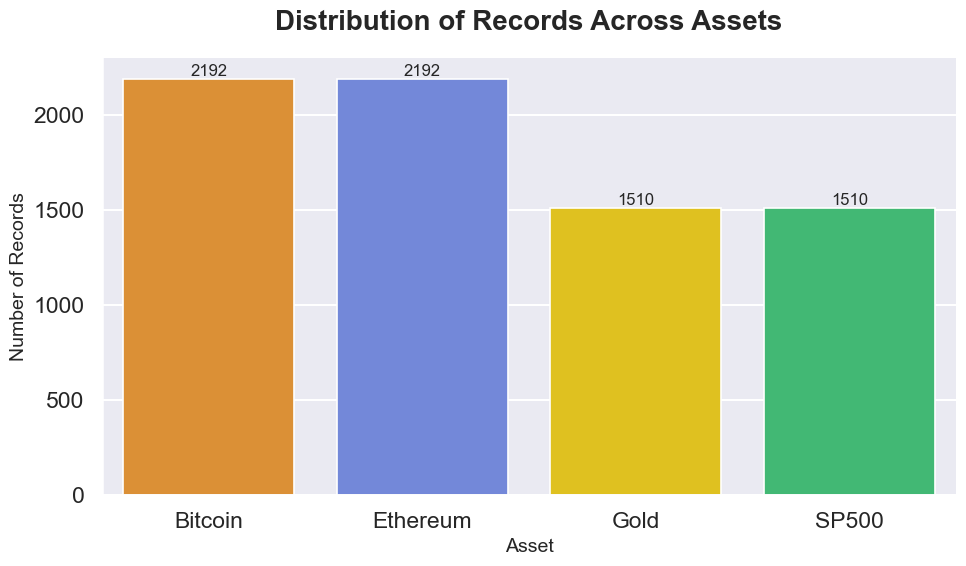

In [9]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=market,
    x="Asset",
    hue="Asset",
    palette= crypto_palette,
    edgecolor="white",
    linewidth=1.2,
    legend= False
)

plt.title(
    "Distribution of Records Across Assets",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Asset", fontsize=14)
plt.ylabel("Number of Records", fontsize=14)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

* **Bitcoin** and **Ethereum** have more records because cryptocurrency markets operate **24/7**, including weekends and holidays.
* **Gold** and the **S&P 500** have fewer records because traditional financial markets are **closed on weekends and public holidays**.
* Therefore, the difference in record counts is **expected** and reflects the different trading schedules of these asset classes, not missing data.


## Closing Price Trend

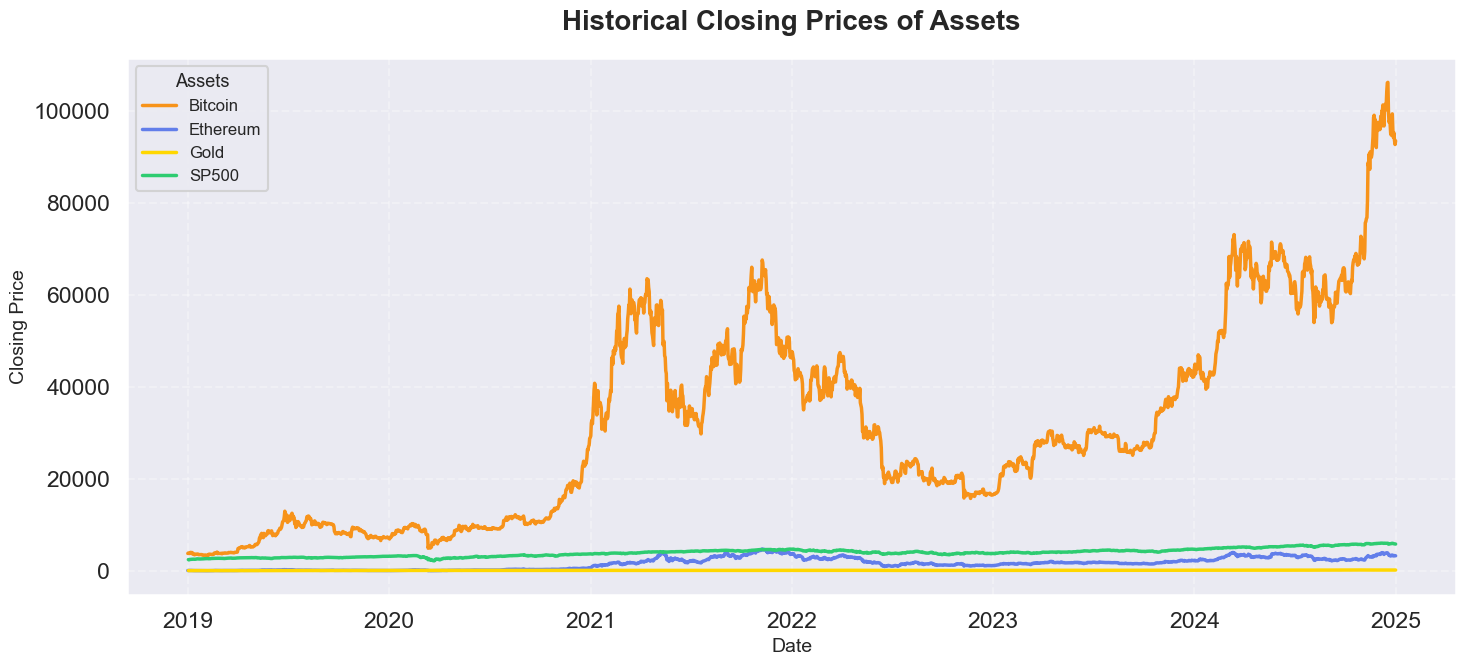

In [10]:
plt.figure(figsize=(15, 7))

# Plot each asset with its predefined color
for asset in market["Asset"].unique():

    subset = market[market["Asset"] == asset]

    plt.plot(
        subset["Date"],
        subset["Close"],
        label=asset,
        color=crypto_palette[asset],
        linewidth=2.5
    )

plt.title(
    "Historical Closing Prices of Assets",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Closing Price", fontsize=14)

plt.grid(alpha=0.3, linestyle="--")

plt.legend(
    title="Assets",
    fontsize=12,
    title_fontsize=13,
    frameon=True
)

plt.tight_layout()
plt.show()

The chart is dominated by Bitcoin's price, making the other assets appear almost flat because they are on very different price scales. Better approach is to normalize the prices so all assets start at the same value (e.g., 100). This allows you to compare relative growth rather than absolute prices.

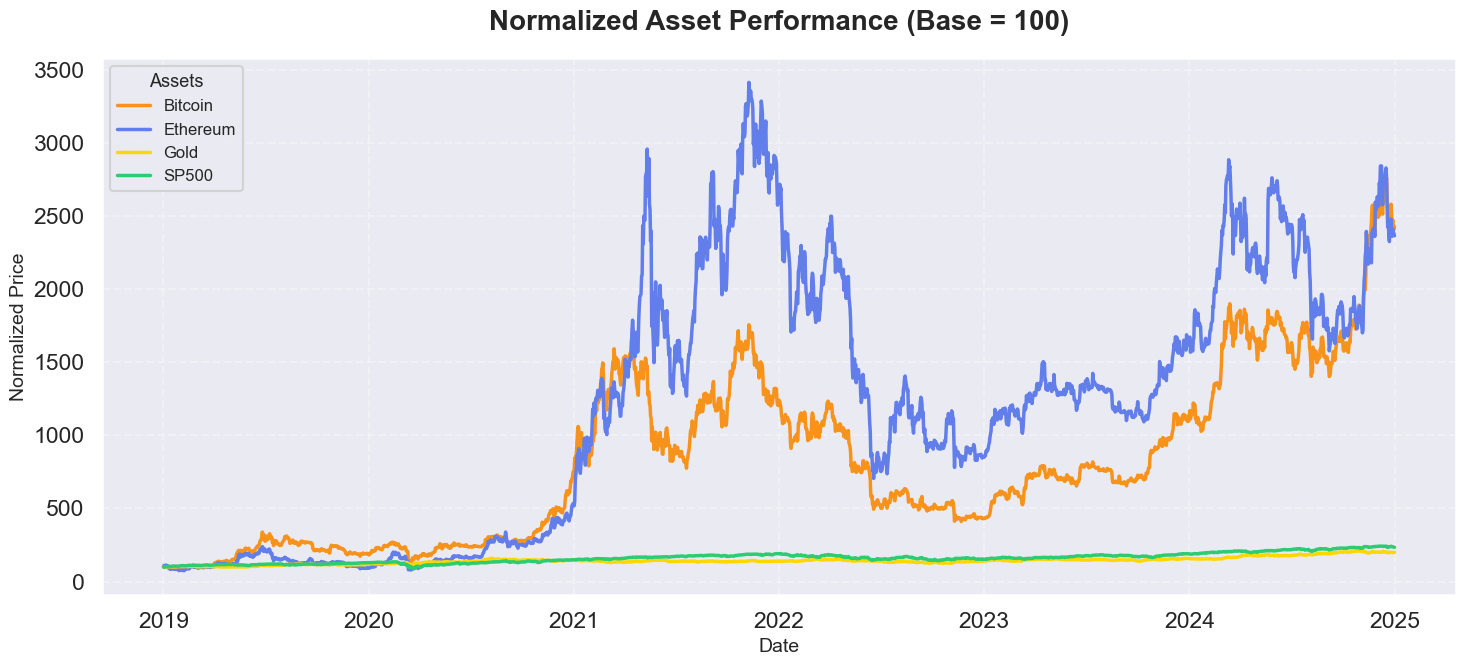

In [11]:
plt.figure(figsize=(15, 7))

for asset in market["Asset"].unique():

    subset = market[market["Asset"] == asset].copy()

    # Normalize prices (Base = 100)
    subset["Normalized_Close"] = (
        subset["Close"] / subset["Close"].iloc[0]
    ) * 100

    plt.plot(
        subset["Date"],
        subset["Normalized_Close"],
        label=asset,
        color=crypto_palette[asset],
        linewidth=2.5
    )

plt.title(
    "Normalized Asset Performance (Base = 100)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Normalized Price", fontsize=14)

plt.grid(alpha=0.3, linestyle="--")

plt.legend(
    title="Assets",
    fontsize=12,
    title_fontsize=13,
    frameon=True
)

plt.tight_layout()
plt.show()

### Interpretation

* All assets are normalized to **100** at the start of the observation period.
* This allows a fair comparison of **relative performance** regardless of differences in their actual price levels.
* An upward trend indicates growth from the initial value, while a downward trend indicates a decline.

 **2020:** All assets show a sharp decline, coinciding with the global market downturn during the COVID-19 period.
 
 **2020–2021:** Bitcoin and Ethereum experienced significantly stronger growth than Gold and the S&P 500.
 
 **2022:** Cryptocurrencies underwent a major correction, while traditional assets remained comparatively stable.
 
 **2023–2024:** Most assets recovered, with cryptocurrencies continuing to exhibit higher volatility.

**Key Insight:** The observed trends align with major market events during the period; however, they represent correlation rather than confirmed causation.

* The chart shows that **Bitcoin and Ethereum experienced much larger price fluctuations**, whereas **Gold and the S&P 500 exhibited comparatively steadier growth**, reflecting their lower volatility.


### Distribution of closing price

In [12]:
market = market.sort_values(["Asset", "Date"])

market["Daily_Return (%)"] = (
    market.groupby("Asset")["Close"]
    .pct_change() * 100
)

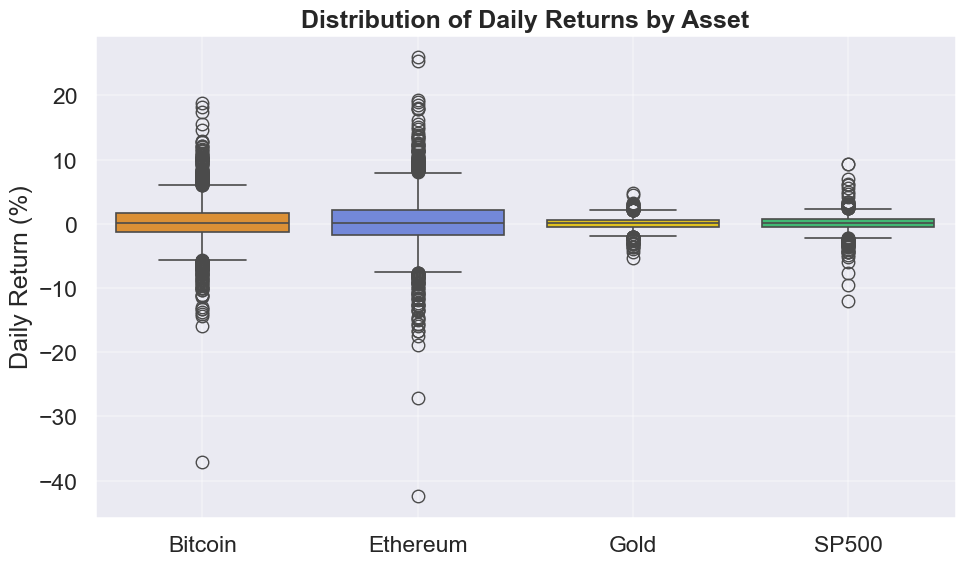

In [13]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=market,
    x="Asset",
    y="Daily_Return (%)",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    linewidth=1.2
)

plt.title(
    "Distribution of Daily Returns by Asset",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Daily Return (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

* **Spread:** Bitcoin and Ethereum exhibit a wider spread, indicating greater price variability than Gold and the S&P 500.
* **Outliers:** Cryptocurrencies show more extreme outliers, reflecting frequent large daily price movements.
* **Volatility:** Gold and the S&P 500 have tighter distributions, suggesting relatively stable daily returns.


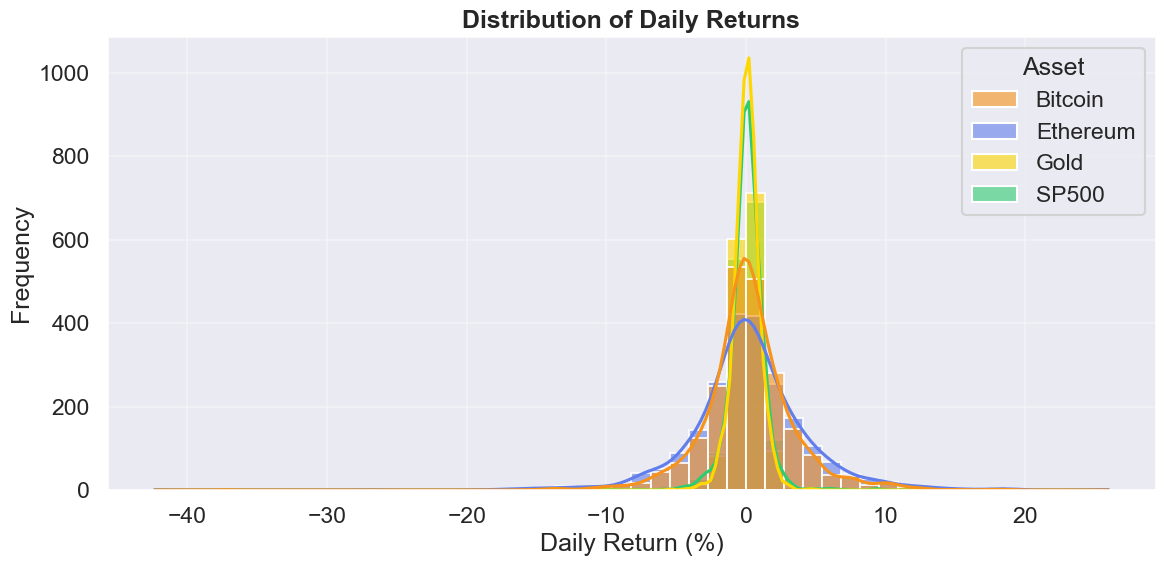

In [14]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=market,
    x="Daily_Return (%)",
    hue="Asset",
    palette=crypto_palette,
    bins=50,
    kde=True,
    alpha=0.6
)

plt.title(
    "Distribution of Daily Returns",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

* **Distribution:** Most daily returns are concentrated around 0%, indicating that small price changes are the most common.
* **Skewness:** Cryptocurrency returns display longer tails, suggesting occasional large gains and losses.
* **Comparison:** Gold and the S&P 500 exhibit narrower distributions, highlighting their comparatively lower volatility.


## Which Assest is traded the most?

In [15]:
volume_summary = (
    market.groupby("Asset")["Volume"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

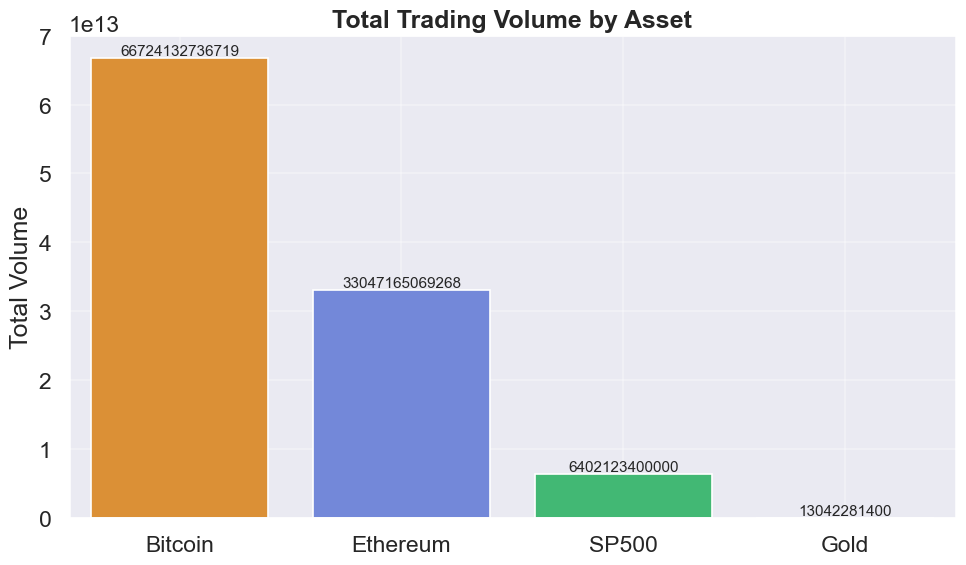

In [16]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=volume_summary,
    x="Asset",
    y="Volume",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Total Trading Volume by Asset",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Total Volume")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=11)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

* The chart compares the **total trading volume** of each asset over the analysis period.
* Assets with higher total volume **(BitCoin)** indicate **greater trading activity and market participation**.
* Trading volume should be interpreted cautiously when comparing different asset classes, as reporting methods and market structures differ between cryptocurrencies and traditional financial markets.


## Yearly Average

In [17]:
market["Year"]=market["Date"].dt.year

In [18]:
market.groupby(
    ["Year","Asset"]
)["Close"].mean().unstack()

Asset,Bitcoin,Ethereum,Gold,SP500
Year,,,,
2019,7395.246282,181.770137,131.516944,2913.356380
2020,11116.378092,307.542978,166.653755,3217.855849
2021,47436.932021,2778.354149,168.311230,4273.385635
2022,28197.754099,1987.393187,167.905139,4098.514748
2023,28859.448250,1795.155852,180.449880,4283.729439
2024,65964.115106,3044.928617,221.099484,5428.235119


### Interpretation

* **Bitcoin** and **Ethereum** recorded rapid growth until **2021**, declined during **2022**, and recovered strongly in **2024**.
* **Gold** showed relatively stable prices with a gradual upward trend, reaching its highest yearly average in **2024**.
* The **S&P 500** experienced moderate growth over the period, with a slight decline in **2022** followed by a steady recovery.
* **Overall, cryptocurrencies exhibited much larger price swings than traditional assets, indicating higher volatility and return potential.**


In [19]:
market.groupby("Asset")[
    ["Open","High","Low","Close","Volume"]
].describe()

Open                                                         \
           count          mean           std          min           25%   
Asset                                                                     
Bitcoin   2192.0  31462.483957  22085.026506  3401.376465  10577.423828   
Ethereum  2192.0   1681.224052   1244.358362   104.645050    275.897514   
Gold      1510.0    172.647709     28.809384   119.669998    159.352505   
SP500     1510.0   4034.069698    864.323900  2290.709961   3278.029968   

                                                       High                \
                   50%           75%            max   count          mean   
Asset                                                                       
Bitcoin   27301.943359  46423.242188  106147.296875  2192.0  32155.585661   
Ethereum   1677.451233   2613.066284    4810.071289  2192.0   1726.227851   
Gold        170.600006    182.657501     256.760010  1510.0    173.387802   
SP500      4077.409912   4513.574829    6089.029785  1510.0   4056.954008   

          ...         Close                 Volume                \
          ...           75%            max   count          mean   
Asset     ...                                                      
Bitcoin   ...  46454.189453  106140.601562  2192.0  3.043984e+10   
Ethereum  ...   2614.874451    4812.087402  2192.0  1.507626e+10   
Gold      ...    182.944996     257.500000  1510.0  8.637272e+06   
SP500     ...   4514.670044    6090.270020  1510.0  4.239817e+09   

                                                                  \
                   std           min           25%           50%   
Asset                                                              
Bitcoin   1.908530e+10  4.324201e+09  1.788499e+10  2.673177e+10   
Ethereum  1.033668e+10  2.081626e+09  7.811163e+09  1.274592e+10   
Gold      4.794221e+06  1.436500e+06  5.558300e+06  7.401850e+06   
SP500     1.033897e+09  0.000000e+00  3.625595e+09  3.999570e+09   

                                      
                   75%           max  
Asset                                 
Bitcoin   3.775100e+10  3.509679e+11  
Ethereum  1.892777e+10  8.448291e+10  
Gold      1.029825e+07  4.734770e+07  
SP500     4.576138e+09  9.976520e+09  

[4 rows x 40 columns]

## Key Findings

• Bitcoin exhibited the largest price fluctuations.

• Ethereum followed a similar trend but with greater volatility.

• Gold remained comparatively stable throughout the study period.

• The S&P 500 experienced a sharp decline during the COVID-19 pandemic but recovered steadily.

These observations motivate a deeper investigation into returns, volatility, and market correlation in the subsequent notebooks.